# Loading dataset + model

In [ ]:
!pip install datasets

In [9]:
# Loading dataset
import datasets
import pandas as pd

df = datasets.load_dataset("imdb", split="test")
df = pd.DataFrame(df)
df = df.sample(10)
df

,text,label
13488,"and there are not many in cinema history. ""Rou...",1
17887,One of the finest movies I have viewed...Good ...,1
6268,Scarier than any horror movie ever made becaus...,0
14891,I was lucky enough to see this film at a festi...,1
13796,"Watching this odd little adventure movie, it's...",1
2015,Jack Frost returns with an army of Styrofoam b...,0
7642,Butter Battle is an entertaining story about t...,0
13492,Trilogies are very interesting. Some go out wi...,1
4007,There's nothing wrong with softcore but this o...,0
11683,*SPOILERS INCLUDED*<br /><br />Alfred Hitchcoc...,0


In [11]:
# Shortening the data
short_df = [s[:500] for s in df["text"][:20]]
short_df[0]

'and there are not many in cinema history. "Rouge" seems to be a bit of a hope. Hope in mankind and in life. But to say only that may be naive. Kieslowski could find the right way to tell the story of that embittered judge and the twentish but wise model. Perhaps that old and disappointing love affair will not be repeated -there\'s the new couple with the young judge after the accident-. But what to say about this master of the camera? You can\'t miss a second of the movie because you have to watch'

In [ ]:
!pip install transformers

In [18]:
# Defining the model pipeline
import transformers
classifier = transformers.pipeline("sentiment-analysis", return_all_scores=True)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [19]:
# Example
texts = ["I love this movie! It was the best movie of all time",
         "I liked the first half but did not like the second half."]
results = classifier(texts)
results

[{'label': 'POSITIVE', 'score': 0.9998692274093628},
 {'label': 'NEGATIVE', 'score': 0.9635261297225952}]

In [21]:
# Sentiment analysis for short_df
classifier(short_df)

[{'label': 'POSITIVE', 'score': 0.9950195550918579},
 {'label': 'POSITIVE', 'score': 0.9991558790206909},
 {'label': 'POSITIVE', 'score': 0.9848769903182983},
 {'label': 'NEGATIVE', 'score': 0.9589365124702454},
 {'label': 'POSITIVE', 'score': 0.8494093418121338},
 {'label': 'NEGATIVE', 'score': 0.9909816384315491},
 {'label': 'POSITIVE', 'score': 0.9055563807487488},
 {'label': 'POSITIVE', 'score': 0.9995927214622498},
 {'label': 'NEGATIVE', 'score': 0.998867392539978},
 {'label': 'POSITIVE', 'score': 0.9992761015892029}]

# Creating the SHAP explainer

In [ ]:
!pip install shap

In [38]:
# Create pipeline
pipeline = shap.models.TransformersPipeline(classifier, rescale_to_logits=True)

In [39]:
# Define the explainer
import shap
explainer = shap.Explainer(pipeline)

In [40]:
# Explain prediction of pipeline on last 2 samples
shap_values = explainer(short_df[:2])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [04:17, 128.61s/it]


In [43]:
shap.plots.text(shap_values)

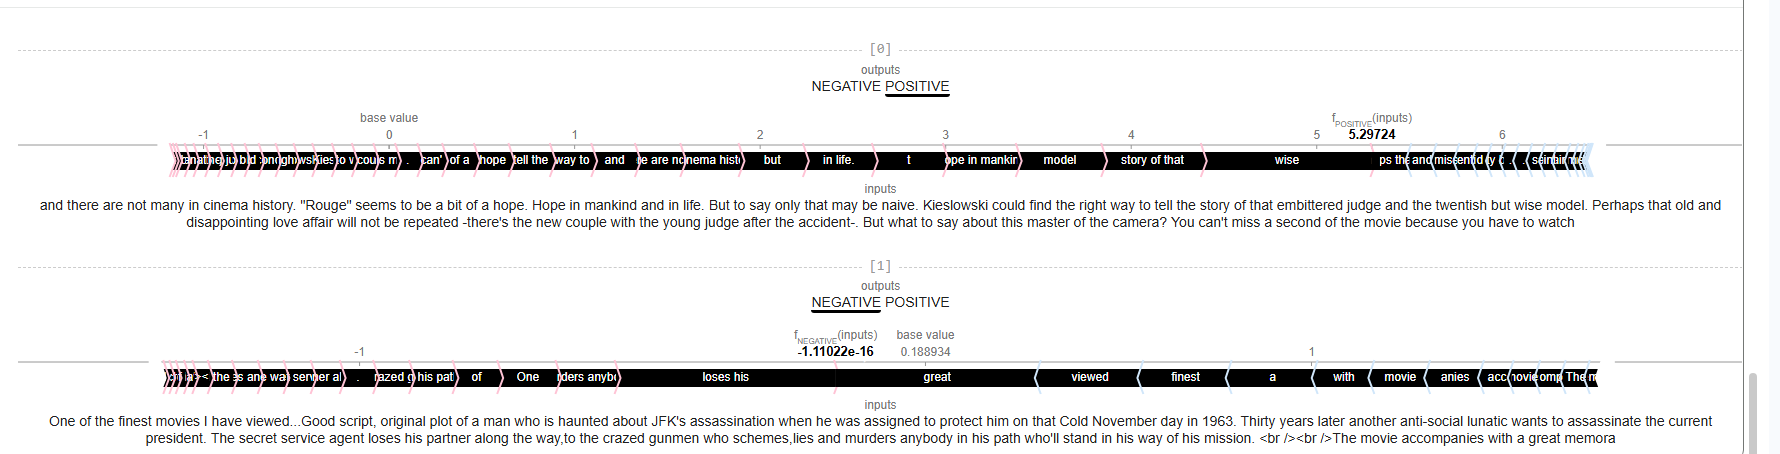